In [1]:
import matplotlib.pyplot as plt                                             #Ziffern plotten
import numpy as np                                                          #csv umwandeln
from ipycanvas import Canvas                                                #Ziffer eingabe
from ipywidgets import VBox, HBox, Button, IntText, Output, Label, Layout   #Design
import os                                                                   #Dateipfad Überprüfung

In [10]:
#Daten vom csv laden

file_path = "data/dataset.csv"

if os.path.exists(file_path) and os.path.getsize(file_path) > 0:    #Überprüfung, ob datei existiert
    dataset_array = np.loadtxt(file_path, delimiter=",", ndmin=2)   #csv in array umwandeln
else:
    dataset_array = np.empty((0, 0))                                #neuer array erstellen

dataset = []        #neues dictionary erstellen

if dataset_array.size > 0:      #Überprüfung, ob array leer ist
    for row in dataset_array:   
        features = row[:-1]     #features aus array extrahieren
        label = int(row[-1])    #labels aus array extrahieren

        dataset.append({                
            "features": features,   #features im dictionary speichern
            "label": label          #labels im dictionary speichern
        })

In [14]:
#Daten in csv speichern 

if len(dataset) > 0:    #Überprüfung, ob dataset Inhalt hat

    rows = []           #Liste für csv erstellen

    for item in dataset:                                    
        row = np.append(item["features"], item["label"])    #features und labels zu einer Zeile kombinieren
        rows.append(row)                                    #neue Zeile zur Liste hinzufügen

    rows = np.array(rows)   #Liste in NumPy-array umwandeln

    np.savetxt("data/dataset.csv", rows, delimiter=",", fmt="%d")   #csv speichern

else:
    print("Dataset ist leer – nichts zum Speichern.")   #Errormeldung

In [11]:
#canvas (560x560 für 16x16 Raster)

#canvas-Zeichenfläche erstellen
canvas_size = 560                                                               
canvas = Canvas(width=canvas_size, height=canvas_size, sync_image_data=True)

#canvas formatieren
canvas.fill_style = 'white'
canvas.fill_rect(0, 0, 560, 560)
canvas.stroke_style = '#333'
canvas.line_cap = 'round'
canvas.line_join = 'round'
canvas.layout = Layout(width='480px', height='480px', border='2px solid black') 

#zeichnen-Status
drawing = False

#speichert vorherige Mausposition
x_prev, y_prev = 0, 0   

def on_mouse_down(x, y):
    global drawing, x_prev, y_prev
    drawing = True
    x_prev, y_prev = x, y

def on_mouse_move(x, y):
    global x_prev, y_prev
    if drawing:
        canvas.stroke_style = 'black'
        canvas.line_width = 40
        canvas.stroke_line(x_prev, y_prev, x, y)
        x_prev, y_prev = x, y

def on_mouse_up(x, y):
    global drawing
    drawing = False

#Mausevents mit functions verbinden
canvas.on_mouse_down(on_mouse_down)
canvas.on_mouse_move(on_mouse_move)
canvas.on_mouse_up(on_mouse_up)

def canvas_to_16x16():
    GRID = 16                               #Zielraster
    W, H = canvas.width, canvas.height
    cell_w, cell_h = W / GRID, H / GRID     #Zellgrössen
    
    img = canvas.get_image_data(0, 0, W, H)     #canvas-Pixel holen
    arr = np.array(img)                         #NumPy-array erstellen
    rgb = arr[..., :3].astype(np.float32)       #alpha ignorireren --> RGB
    
    gray = rgb.mean(axis=2) / 255.0     #Graustufen berechnen

    features = np.zeros((GRID, GRID), dtype=np.int32)   #NumPy-array für features erstellen

    for gy in range(GRID):                  #durch alle Zellen gehen
        for gx in range(GRID):
            y0 = int(gy * cell_h)           #Bereich der Zelle bestimmen
            y1 = int((gy + 1) * cell_h)
            x0 = int(gx * cell_w)
            x1 = int((gx + 1) * cell_w)

            patch = gray[y0:y1, x0:x1]                              #Werte dieser Zelle holen
            mean_val = patch.mean() if patch.size > 0 else 0.0      #Durchscnitt berechnen

            val = int(round(mean_val * 16))     #Werte skalieren (0-16)

            features[gy, gx] = val      #Wert speichern

    return features.flatten()  #2D-array zu 1D-array umwandeln

dataset = []

#buttons
label_input = IntText(value=0, description='Label:')                            #Eingabefeld: Label
save_btn = Button(description='Speichern', button_style='success')              #button: Speichern 
clear_btn = Button(description='Zeichnung löschen', button_style='warning')     #button: Löschen
status = Label(value='Zeichne eine Ziffer und gib ein Label ein.')              #Statusanzeige

def clear_canvas(_):
    canvas.fill_style = 'white'
    canvas.fill_rect(0, 0, canvas.width, canvas.height)
    canvas.stroke_style = '#333'
    
    status.value = 'Canvas geleert – zeichne neu.'

def save_sample(_):
    label = int(label_input.value)
    features = canvas_to_16x16()
    sample = {'features': features, 'label': label}
    dataset.append(sample)

    canvas.fill_style = 'white'
    canvas.fill_rect(0, 0, canvas.width, canvas.height)
    canvas.stroke_style = '#333'

    status.value = f'Gespeichert: Label {label}, insgesamt {len(dataset)} Daten.'

save_btn.on_click(save_sample)      #buttons verbinden
clear_btn.on_click(clear_canvas)

#UI erstellen
ui = VBox([                                     
    HBox([label_input, save_btn, clear_btn]),
    status,
    canvas
])

display(ui)

In [4]:
#Funktion um Daten zu plotten

def plotImage(pixelmap, ax = None):
    if not ax:
        ax = plt.gca()                                       #holt aktuellen Plotbereich 
    ax.set_yticks([]);ax.set_xticks([])                      #entfernt Achsenbeschriftung
    ax.imshow(np.reshape(pixelmap, (16,16)), cmap="grey")    #Zeigt Bild an und reshaped die Daten in 16x16 Felder

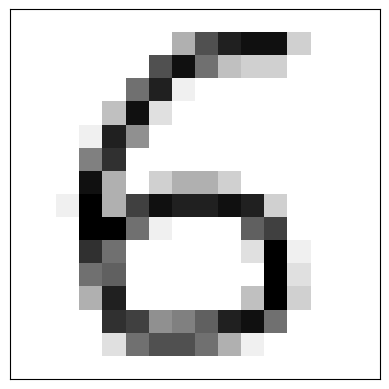

In [6]:
plotImage(dataset[0]["features"])

In [5]:
print(dataset)

[{'features': array([16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16, 16, 16,  9,  5,  9, 15, 16, 16, 16, 16, 16, 16, 16,
       16, 16, 16, 16,  4,  0,  4,  2,  6, 16, 16, 16, 16, 16, 16, 16, 16,
       16, 16,  8,  2, 15, 16, 14,  1,  9, 16, 16, 16, 16, 16, 16, 16, 16,
       16,  1, 11, 16, 16, 16, 12,  1, 12, 16, 16, 16, 16, 16, 16, 16, 13,
        1, 16, 16, 16, 16, 16,  8,  4, 16, 16, 16, 16, 16, 16, 16, 10,  4,
       16, 16, 16, 16, 16, 15,  1, 13, 16, 16, 16, 16, 16, 16,  8,  6, 16,
       16, 16, 16, 16, 16,  5,  7, 16, 16, 16, 16, 16, 16,  7,  6, 16, 16,
       16, 16, 16, 16,  9,  4, 16, 16, 16, 16, 16, 16,  7,  6, 16, 16, 16,
       16, 16, 16, 10,  4, 16, 16, 16, 16, 16, 16,  9,  4, 16, 16, 16, 16,
       16, 16,  9,  4, 16, 16, 16, 16, 16, 16, 14,  1,  9, 16, 16, 16, 15,
       11,  3,  7, 16, 16, 16, 16, 16, 16, 16, 12,  2,  1,  2,  2,  0,  2,
        7, 15, 16, 16, 16, 16, 16, 16, 16, 16, 16, 13, 11, 11, 13, 16, 16,
       16, 

In [13]:
count = sum(1 for item in dataset if item["label"] == 1)
print(count)

1
